In [1]:
from sklearn import datasets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import math

In [2]:
mean = [1 for _ in range(100)]

In [3]:
cov_1 = [0.5 for _ in range(100)]
cov_mat_1 = np.diag(cov_1)
cov_mat_1

array([[0.5, 0. , 0. , ..., 0. , 0. , 0. ],
       [0. , 0.5, 0. , ..., 0. , 0. , 0. ],
       [0. , 0. , 0.5, ..., 0. , 0. , 0. ],
       ...,
       [0. , 0. , 0. , ..., 0.5, 0. , 0. ],
       [0. , 0. , 0. , ..., 0. , 0.5, 0. ],
       [0. , 0. , 0. , ..., 0. , 0. , 0.5]])

In [4]:
cov_2 = [1.0 for _ in range(100)]
cov_mat_2 = np.diag(cov_2)
cov_mat_2

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [5]:
def generate_data():
    A1 = np.random.multivariate_normal(mean, cov_mat_1 ,40)  #normal
    A2 = np.random.multivariate_normal(mean, cov_mat_2 ,40) 
    l_1 = [f'f{i}' for i in range(1, 101)]
    df_A1 = pd.DataFrame(A1, columns = l_1)
    df_A2 = pd.DataFrame(A2, columns = l_1) 
    df = pd.concat([df_A1, df_A2], axis = 0, ignore_index = True)
    X = df.to_numpy(dtype = None, copy = False)
    return X

In [6]:
def calculate_dist_mat(X):
    dist_mat= np.zeros((len(X),len(X)))
    for i in range(1, len(dist_mat[0])):
        for j in range(i):
            for k in range(len(dist_mat[0])):
                if k == i or k == j:
                    continue
                dist_mat[i][j] += abs(np.linalg.norm(X[i] - X[k]) - np.linalg.norm(X[j] - X[k]))
            dist_mat[i][j] /= (len(dist_mat[0])-2)
    return dist_mat

In [7]:
def calculate_Madd(X,i,j):
    madd = 0.0
    for k in range(len(X)):
        if k == i or k == j:
            continue
        madd += abs(np.linalg.norm(X[i] - X[k]) - np.linalg.norm(X[j] - X[k]))
    madd /= (len(X) - 2)
    return madd

In [8]:
def ret_min(a, b): # Returns minimum of a and b
  if a>b:
    return b

  return a

In [9]:
from collections.abc import Iterable

def flatten(lis):
     for item in lis:
         if isinstance(item, Iterable) and not isinstance(item, str):
             for x in flatten(item):
                 yield x
         else:        
             yield item

In [10]:
def within_cluster_distance(X,hierarchy):
  w = []  
  for i in range(len(hierarchy)):
    s1 = 0
    cluster = sorted(list(flatten(hierarchy[i])))
    if len(cluster) == 1:
        w += [0]
        continue
            
    else:
      for j in range(len(cluster)-1):
        for k in range(j+1,len(cluster)):
           s1 += calculate_Madd(X,cluster[j],cluster[k])
      s1 /= (len(cluster)*(len(cluster)-1))/2
      w += [s1]
    
  return w

In [11]:
def between_cluster_distance(X,b,hierarchy):
  
  b_min = float("inf")
  for i in range(len(hierarchy)-1):
    cluster_1 = sorted(list(flatten(hierarchy[i])))
    for j in range(i+1,len(hierarchy)):
      s2 = 0.0
      cluster_2 = sorted(list(flatten(hierarchy[j])))
      for k in range(len(cluster_1)):
        for l in range(len(cluster_2)):
          s2 += calculate_Madd(X,cluster_1[k], cluster_2[l])
      s2 /= (len(cluster_1) * len(cluster_2))
      b[i][j] = s2
      
           
  return b
           

In [12]:
def calculate_between_cluster_distance(b,min_i,min_j,n1,n2):
    for i in range(len(b)):
        if i<min_i:
            b[i][min_i] = (n1*b[i][min_i]+n2*b[i][min_j])/(n1+n2)
        elif i>min_j:
            b[min_i][i] = (n1*b[min_i][i]+n2*b[min_j][i])/(n1+n2)
    
    b = np.delete(b, (min_j), axis=0) # Deleting  min_j row
    b = np.delete(b, (min_j), axis=1) # Deleting  min_j column
    return b

In [13]:
def within_max(w):
    max = w[0]
    for i in range(1,len(w)):
        if w[i] >= max:
            max = w[i]
            
    return max
    

In [14]:
def between_min(b):
    min = b[0][1]
    for i in range(len(b[0])):
        for j in range(i+1,len(b[0])):
            if b[i][j] <= min and (j-i) == 1:
                min = b[i][j]
    return min         

In [15]:
def clustering(X,matrix, hierarchy,d,k_max,w,b):
  
  # Base case
  if len(matrix) == 2:
    min_i = 0
    min_j = 1
    n1 = len(list(flatten(hierarchy[min_i])))
    n2 = len(list(flatten(hierarchy[min_j])))
    hierarchy = hierarchy[:min_i] + [[hierarchy[min_i], hierarchy[min_j]]] + hierarchy[min_j+1:]
    B = d[-1]
    d = d[:-1]
    w = (n1*(n1-1)*w[min_i]+n2*(n2-1)*w[min_j]+2*n1*n2*b[min_i][min_j])/((n1+n2)*(n1+n2-1))
    d += [(B/w) - 0.015 * len(hierarchy) * math.log(100,10)]

    max = d[0]
    index = 0
    for i in range(1,len(d)):
        if d[i] > max:
            max = d[i]
            index = i
    return k_max-index
    




  min = matrix[1][0] #initializing minimum distance
  min_i, min_j = 1, 0

  for i in range(1, len(matrix[0])):
    for j in range(i):
      if i>j and ((i-j) == 1):
        if matrix[i][j]<min:
          min = matrix[i][j]
          min_i = i
          min_j = j

  # Swapping min_i, min_j in order to maintain min_i < min_j
  if min_i > min_j:
    a = min_i
    min_i = min_j
    min_j = a
  
  n1 = len(list(flatten(hierarchy[min_i])))
  n2 = len(list(flatten(hierarchy[min_j])))

  hierarchy = hierarchy[:min_i] + [[hierarchy[min_i], hierarchy[min_j]]] + hierarchy[min_j+1:]

  dist_mat = np.copy(matrix) # Copying the original matrix so that original matrix is not affected by further operations
  dist_mat = np.delete(dist_mat, (min_j), axis=0) # Deleting  min_j row
  dist_mat = np.delete(dist_mat, (min_j), axis=1) # Deleting  min_j column

  dist_min_i = [] # List of distances from point min_i to all other points except min_j
  dist_min_j = [] # List of distances from point min_j to all other points except min_i

  for i in range(len(matrix)):
    if i<min_i:
      dist_min_i += [matrix[min_i][i]]
      dist_min_j += [matrix[min_j][i]]
    elif i == min_i or i == min_j:
      continue
    elif i<min_j:
      dist_min_i += [matrix[i][min_i]]
      dist_min_j += [matrix[min_j][i]]
    else:
      dist_min_i += [matrix[i][min_i]]
      dist_min_j += [matrix[i][min_j]]
  
  # Filling the min_i  row of new distance matrix
  for i in range(len(dist_min_i)):
    if i < min_i:
      dist_mat[min_i][i] = ret_min(dist_min_i[i], dist_min_j[i])
    else:
      dist_mat[i+1][min_i] = ret_min(dist_min_i[i], dist_min_j[i])
  
  dist_min_i = []
  dist_min_j = []
  
  
  
 
  l_h = len(hierarchy)
  if (l_h <= k_max and l_h > 1):
    if(l_h == k_max):
        #b_min = between_cluster_distance(hierarchy,X)
        w = within_cluster_distance(X,hierarchy)
        b = between_cluster_distance(X,b,hierarchy)
        w_max = within_max(w)
        b_min = between_min(b)
        d += [(b_min/w_max) - 0.015 * l_h * math.log(100,10)]
    else:
        w[min_i] = (n1*(n1-1)*w[min_i]+n2*(n2-1)*w[min_j]+2*n1*n2*b[min_i][min_j])/((n1+n2)*(n1+n2-1))
        w = w[:min_j]+w[min_j+1:]
        b = calculate_between_cluster_distance(b,min_i,min_j,n1,n2)
        w_max = within_max(w)
        b_min = between_min(b)
        d += [(b_min/w_max)- 0.015 * l_h * math.log(100,10)]
        if(l_h == 2):
            d += [b_min]

  opt_max = clustering(X,dist_mat, hierarchy,d,k_max,w,b) # The recusion call

  return opt_max

In [16]:
opt_cluster = []
#hier1 = [[i] for i in range(len(dist_mat_1))]
for _ in range(100):
    X = generate_data()
    dist_mat = calculate_dist_mat(X)
    k_max = 20
    b = np.zeros((k_max,k_max))
    hier1 = [[i] for i in range(len(dist_mat))]
    opt_cluster += [clustering(X,dist_mat, hier1,[],20,[],b)]

In [17]:
opt_cluster

[2,
 5,
 2,
 2,
 2,
 2,
 2,
 4,
 1,
 2,
 1,
 2,
 2,
 2,
 2,
 4,
 2,
 3,
 2,
 1,
 1,
 1,
 3,
 3,
 4,
 2,
 1,
 2,
 4,
 3,
 2,
 2,
 1,
 2,
 1,
 2,
 2,
 2,
 1,
 1,
 4,
 4,
 2,
 4,
 4,
 2,
 2,
 2,
 2,
 2,
 1,
 2,
 2,
 2,
 2,
 2,
 1,
 2,
 2,
 2,
 1,
 2,
 2,
 2,
 2,
 1,
 2,
 2,
 2,
 2,
 1,
 2,
 2,
 2,
 2,
 2,
 4,
 1,
 2,
 4,
 2,
 2,
 1,
 2,
 1,
 2,
 4,
 4,
 2,
 2,
 2,
 3,
 6,
 1,
 2,
 3,
 2,
 1,
 2,
 1]

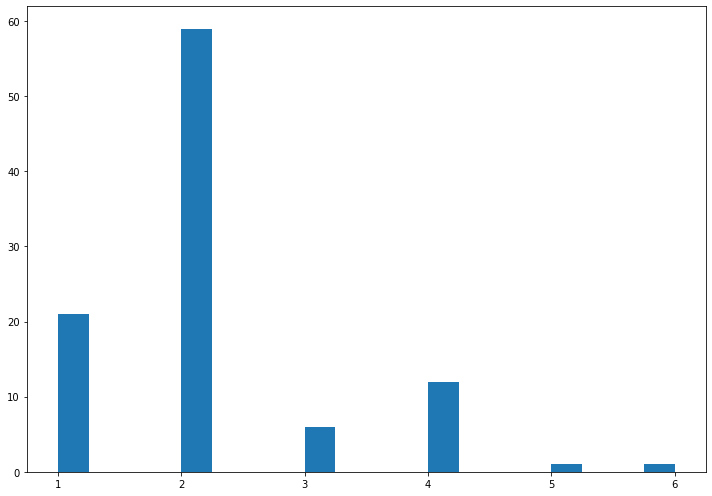

In [18]:
# Creating histogram
n_bins = 20
fig, axs = plt.subplots(1, 1,
                        figsize =(10, 7),
                        tight_layout = True)
 
axs.hist(opt_cluster, bins = n_bins)
 
# Show plot
plt.show()